In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import PercentFormatter

In [18]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [19]:
df 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [21]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [22]:
df['Contract'].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

In [23]:
df2 = df.copy()

In [24]:
df2['Churn'] = df2['Churn'].map({'Yes': 1, 'No': 0})

Text(0.5, 0, 'Tipo de Contrato')

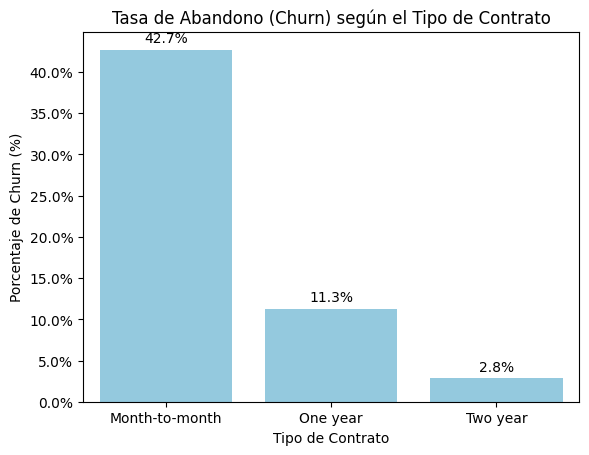

In [25]:
ax = sns.barplot(data=df2, x='Contract', y='Churn', errorbar=None, color='skyblue')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas, padding=3)
plt.title('Tasa de Abandono (Churn) según el Tipo de Contrato')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('Tipo de Contrato')

Los clientes más propensos a abandonar el servicio son los que pagan el servicio de mes a mes, por lo que lo mejor sería ofrecerles alternativas para que cambiar su plan de pago.

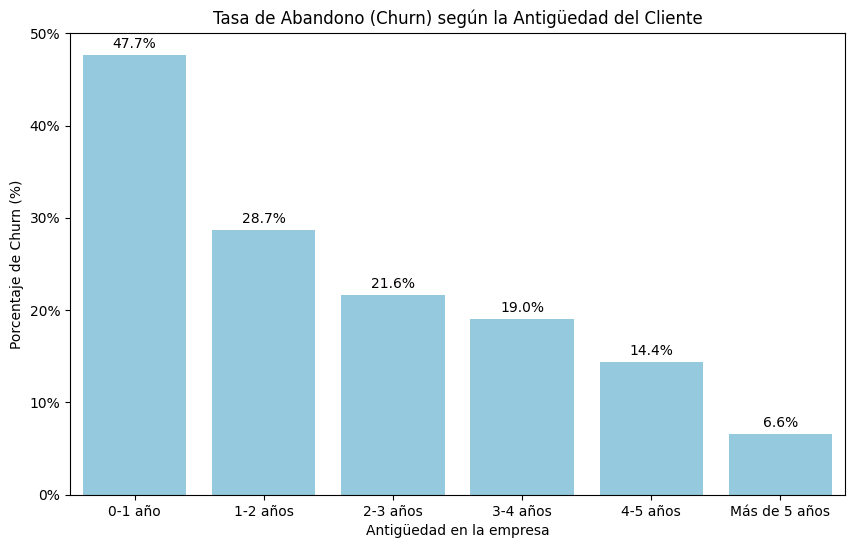

In [26]:
limites = [0, 12, 24, 36, 48, 60, 75] 
nombres_intervalos = ['0-1 año', '1-2 años', '2-3 años', '3-4 años', '4-5 años', 'Más de 5 años']

df2['tenure_group'] = pd.cut(df2['tenure'], bins=limites, labels=nombres_intervalos)
plt.figure(figsize=(10, 6)) 
ax = sns.barplot(data=df2, x='tenure_group', y='Churn', errorbar=None, color='skyblue')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
etiquetas_barras = [f"{barra.get_height():.1%}" for barra in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=etiquetas_barras, padding=3)

plt.title('Tasa de Abandono (Churn) según la Antigüedad del Cliente')
plt.ylabel('Porcentaje de Churn (%)')
plt.xlabel('Antigüedad en la empresa')

plt.show()

La mayor tasa de abandono del servicio ocurre durante el primer año, ya se disminuye con el tiempo.

Text(0.5, 0, 'Tipo de Contrato')

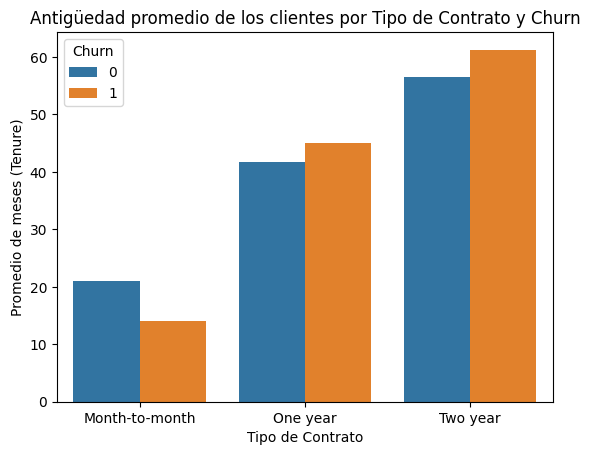

In [27]:
ax = sns.barplot(data=df2, x='Contract', y='tenure', hue='Churn', errorbar=None)
plt.title('Antigüedad promedio de los clientes por Tipo de Contrato y Churn')
plt.ylabel('Promedio de meses (Tenure)')
plt.xlabel('Tipo de Contrato')

Muestra en promedio cuántos meses aguanta un cliente antes de abandonar el servicio según el tipo de contrato.

In [33]:
df_limpio = df.drop(columns=['customerID'])

In [43]:
df_limpio.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [42]:
df_limpio['TotalCharges'] = pd.to_numeric(df_limpio['TotalCharges'], errors='coerce')

In [45]:
df_limpio.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64

In [46]:
df_dividido = pd.get_dummies(df_limpio, drop_first=True)

In [47]:
correlacion = df_dividido.corr()

In [48]:
correlacion

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
SeniorCitizen,1.000000,0.016567,0.220173,0.102411,-0.001874,0.016479,-0.211185,0.008576,-0.008576,0.142948,...,0.105378,-0.182742,0.120176,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477,0.150889
tenure,0.016567,1.000000,0.247900,0.825880,0.005106,0.379697,0.159712,0.008448,-0.008448,0.331941,...,0.279756,-0.039062,0.286111,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852,-0.352229
MonthlyCharges,0.220173,0.247900,1.000000,0.651065,-0.014569,0.096848,-0.113890,0.247398,-0.247398,0.490434,...,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437,0.193356
TotalCharges,0.102411,0.825880,0.651065,1.000000,0.000048,0.319072,0.064653,0.113008,-0.113008,0.469042,...,0.515709,-0.374878,0.519867,0.170569,0.358036,0.157830,0.182663,-0.060436,-0.294708,-0.199484
gender_Male,-0.001874,0.005106,-0.014569,0.000048,1.000000,-0.001808,0.010517,-0.006488,0.006488,-0.008414,...,-0.008393,0.006026,-0.010487,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744,-0.008612
Partner_Yes,0.016479,0.379697,0.096848,0.319072,-0.001808,1.000000,0.452676,0.017706,-0.017706,0.142057,...,0.124666,0.000615,0.117412,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125,-0.150448
Dependents_Yes,-0.211185,0.159712,-0.113890,0.064653,0.010517,0.452676,1.000000,-0.001762,0.001762,-0.024526,...,-0.016558,0.139812,-0.039741,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071,-0.164221
PhoneService_Yes,0.008576,0.008448,0.247398,0.113008,-0.006488,0.017706,-0.001762,1.000000,-1.000000,0.279690,...,-0.022574,0.172209,-0.032959,-0.002791,0.003519,0.016505,-0.007721,0.003062,-0.003319,0.011942
MultipleLines_No phone service,-0.008576,-0.008448,-0.247398,-0.113008,0.006488,-0.017706,0.001762,-1.000000,1.000000,-0.279690,...,0.022574,-0.172209,0.032959,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319,-0.011942
MultipleLines_Yes,0.142948,0.331941,0.490434,0.469042,-0.008414,0.142057,-0.024526,0.279690,-0.279690,1.000000,...,0.257152,-0.210564,0.258751,-0.003794,0.106253,0.163530,0.060048,0.083618,-0.227206,0.040102


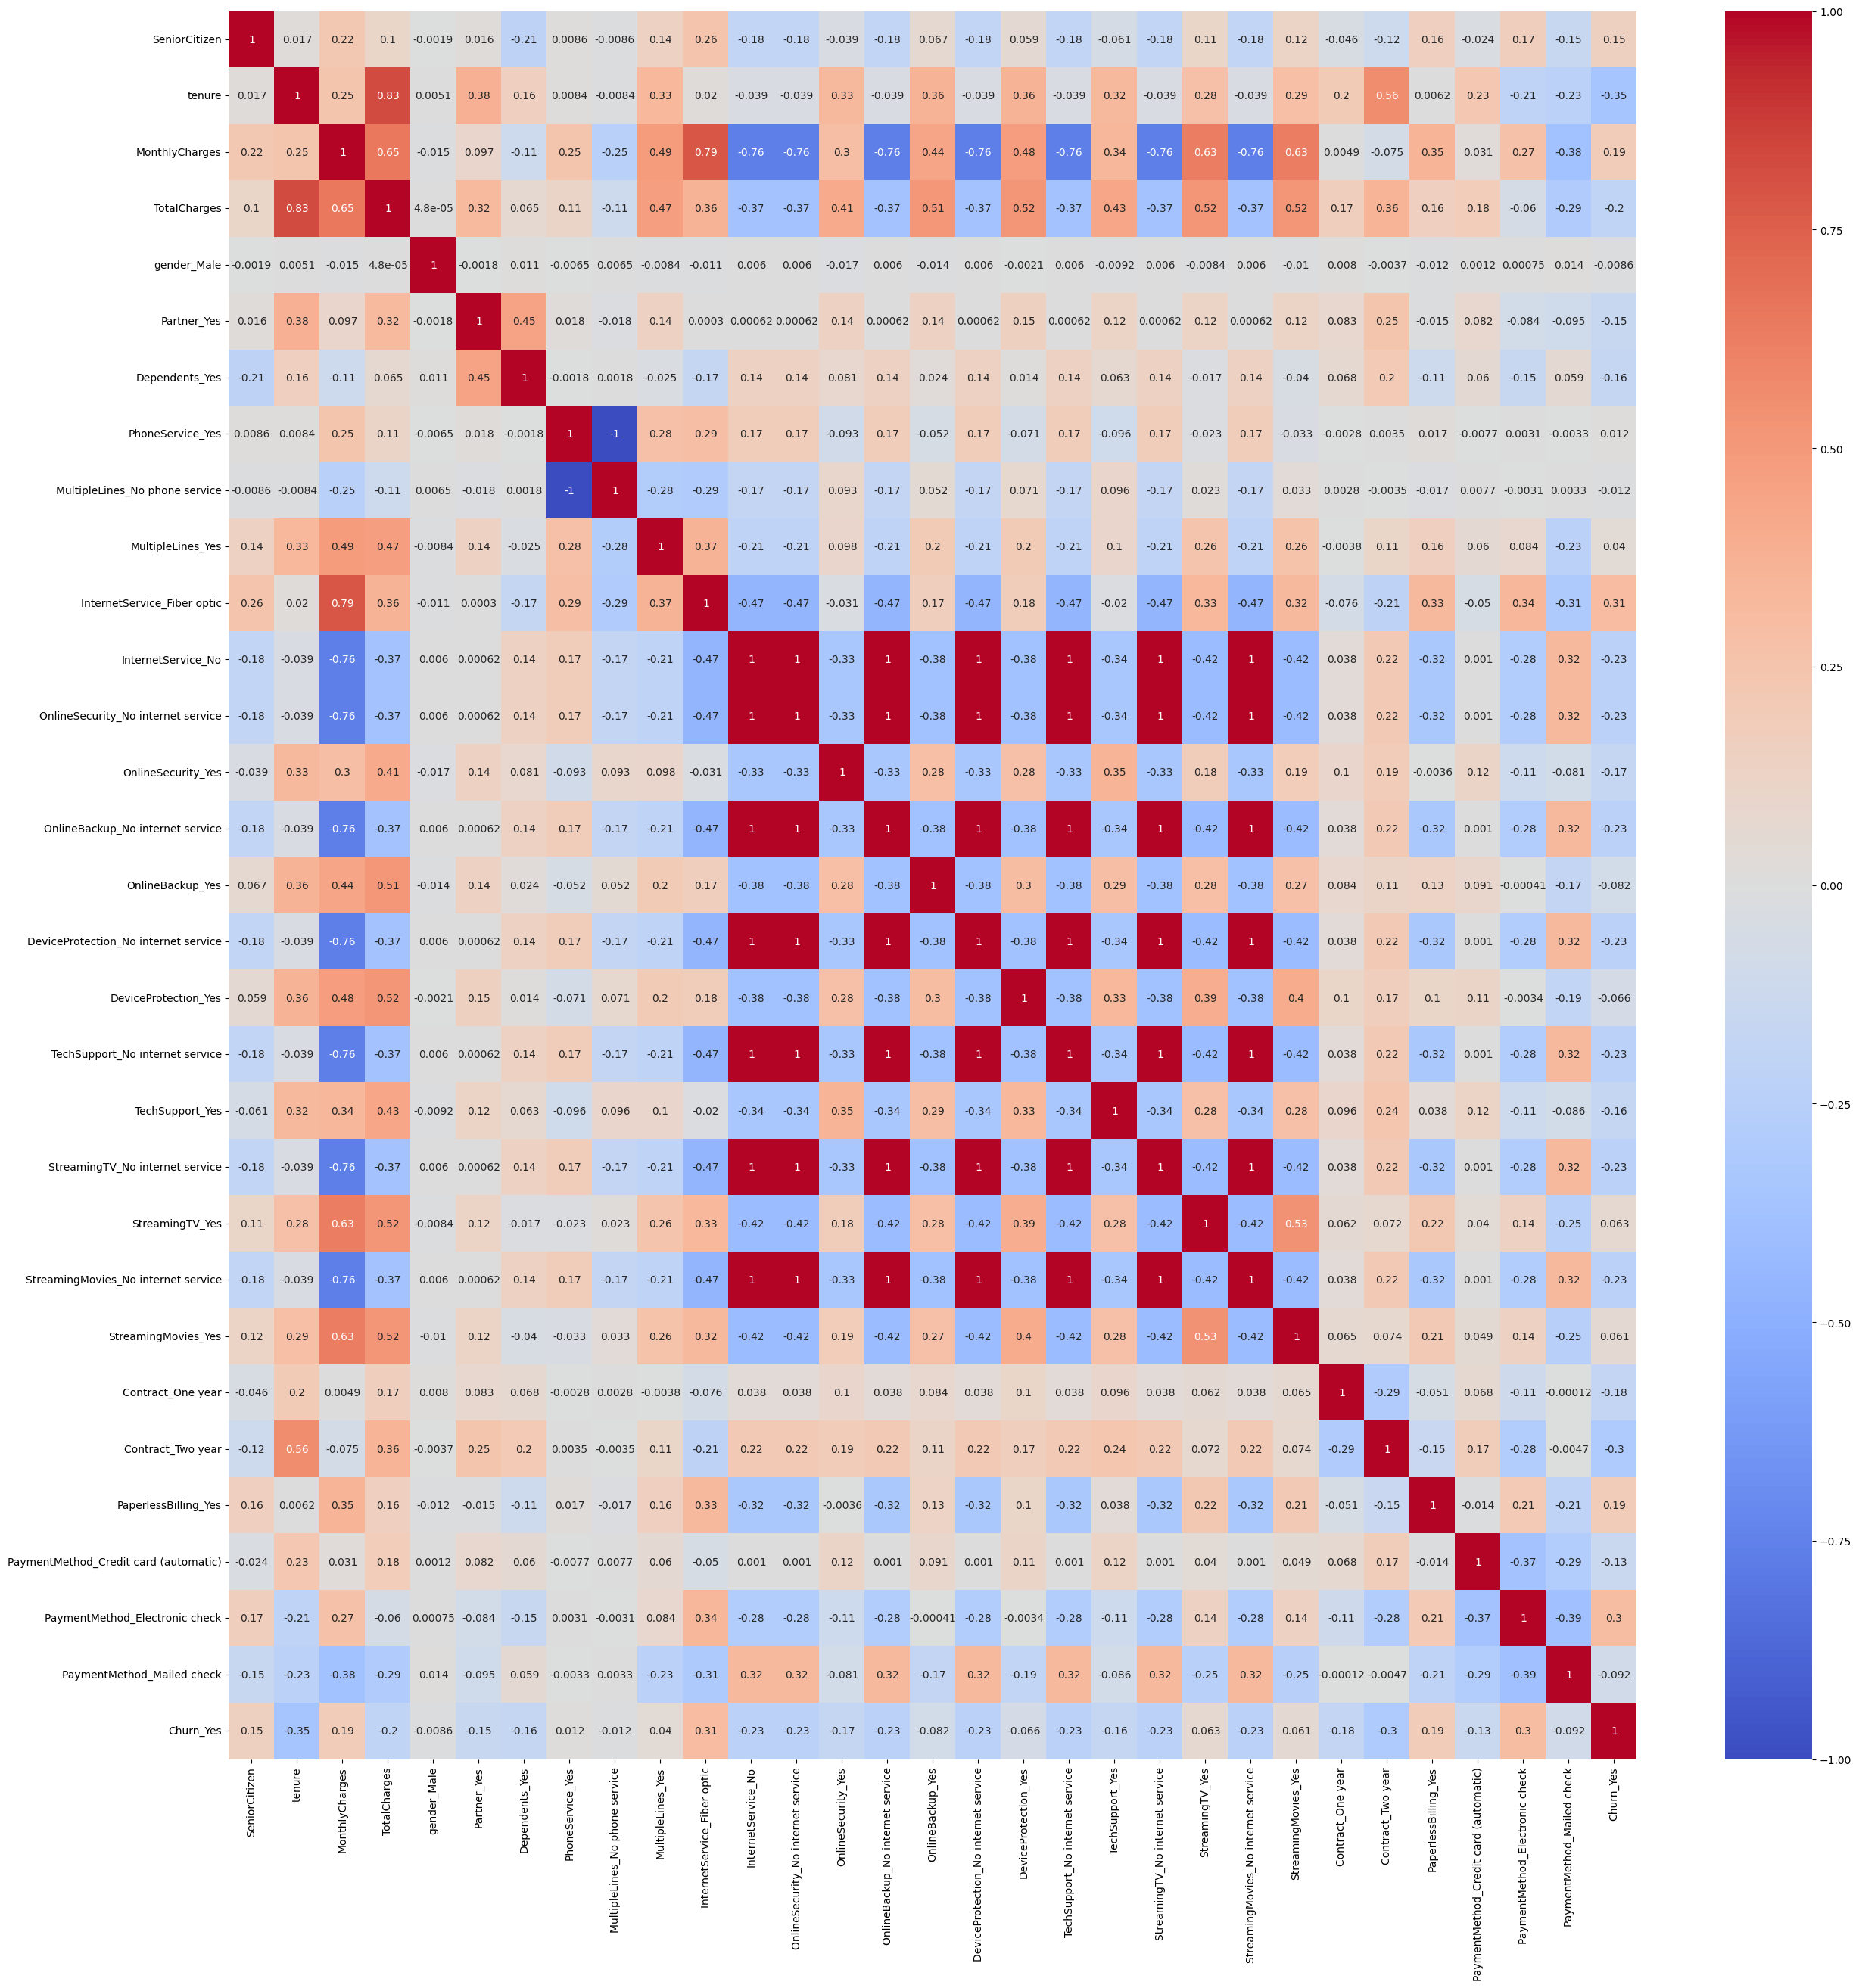

In [51]:
plt.figure(figsize=(30, 30))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.show()